In [41]:
import sys
import os
import torch
import importlib
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('../nodes_2')


import JN_GP as GP
import ecmm_node_cleaner_swell_GP_lib as _lib


def import_reload():
    plot_settings.apply()
    importlib.reload(GP)
    importlib.reload(_lib)


import_reload()
from ecmm_node_cleaner_swell_GP_lib import *

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 32, 'R1_constrained': 'true', 'R1_min': 0.005, 'R1_max': 0.2, 'C1_constrained': 'false', 'C1_min': 500.0, 'C1_max': 50000.0, 'R0_constrained': 'true', 'R0_min': 0.008, 'R0_max': 0.015}
R1 constrained to [0.005, 0.2] Ohm
C1 unconstrained
R0 constrained to [0.008, 0.015] Ohm
R1: [0.00547223 0.00544379]
R1 (manual):  [0.005472233053296804, 0.005443788133561611]
max abs diff: 4.656612873077393e-10


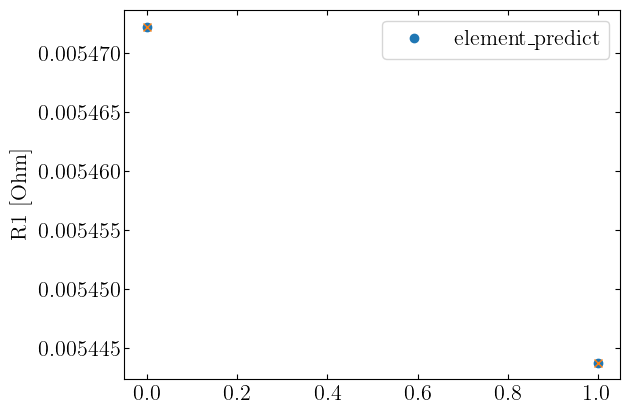

In [ ]:
NODES_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'nodes_2'))

def load_nn_model(model_name, I_ref=24.79):
    ckpt_file = os.path.join(NODES_DIR, 'models', model_name)
    ckpt      = torch.load(ckpt_file, map_location='cpu', weights_only=False)

    CONFIG = ckpt['config']
    print(f"Loaded checkpoint with config: {CONFIG}")

    I_ref_used = ckpt.get('I_ref', I_ref)  # Use persisted I_ref if model saved it, else default
    
    model = BatteryECMM(CONFIG, I_ref=I_ref_used)
    model.load_state_dict(ckpt['model'])
    model.eval()
    return model, ckpt

# –––––––––––– Load model –––––––––––––
model_name = 'ecm_node_0430_1313_staged_swelling_netR0_25.28min_32h_2000_100_S2b20eps.pt'
bat_model, ckpt = load_nn_model(model_name)
# history, CONFIG, C1_final, N_HIDDEN, EPOCHS_STATIC, EPOCHS_DYNAMIC, EPOCHS_UNFREEZE = load_checkpoint(ckpt)


# ––––––––––––– Obtain elements –––––––––––––
c_rate = [2.0, 2.0]       # List or not list is ok
u_per  = [5, 5]
soc    = [0.7, 0.8]

# Use packaged function to predict R1 for all points at once
R1, C1, R0, k, s = element_predict(bat_model, c_rate=c_rate, u_per=u_per, soc=soc)  # Or specifiy element='R1' to get just R1
print("R1:", R1)


# ––––––––– Don't use this!? –––––––––––

# Manual per-point predict
Q0  = 17921.57581
L0  = 14.37325
R1_manual = []
for cr, up, sc in zip(c_rate, u_per, soc):
    I_norm = torch.tensor([cr * Q0 / 3600.0 / bat_model.I_ref], dtype=torch.float32)
    u_t    = torch.tensor([up * L0],                             dtype=torch.float32)
    soc_t  = torch.tensor([sc],                                  dtype=torch.float32)
    with torch.no_grad():
        R1_manual.append(bat_model._R1(soc_t, I_norm, u_t).item())
print("R1 (manual): ", R1_manual)
print("max abs diff:", float(np.max(np.abs(np.array(R1) - np.array(R1_manual)))))

plt.plot(R1, 'o', label='element_predict')
plt.plot(R1_manual, 'x', label='_R1 direct')
plt.legend(); plt.ylabel('R1 [Ohm]'); plt.show()